# Cluster stellar luminosities from $K_s$ photometry

This notebook replaces the original numbered APG17 notebooks with one sequential,
restartable workflow. It:

1. loads and validates the stellar catalogue;
2. applies an optional cluster metallicity;
3. derives distances from a fixed distance modulus, a combined RGB+RC weighted-
   median corrected parallax, individual parallaxes, or fixed distance/parallax;
4. obtains extinction from Bayestar 2019 or uses a fixed cluster $E(B-V)$/$A_{K_s}$;
5. runs the external Casagrande & VandenBerg bolometric-correction code;
6. computes luminosities and their propagated uncertainties;
7. writes a compact catalogue and saves an HR diagram.

Edit **only the configuration cell below** for a new catalogue or cluster, then use
**Run All**. The original input columns remain in the full output, and explicit
`*_used` columns record every value used in the calculation.

In [1]:
# import os
# https://github.com/amiglio/luminosity_gaia_seismo/tree/main

# print(os.getcwd())

## 0. Configuration

Paths may be absolute or relative to this notebook. The three mode switches are:

- `DISTANCE_MODE`: `"fixed_distance_modulus"`,
  `"cluster_weighted_median_parallax"`, `"per_star_parallax"`,
  `"fixed_parallax"`, or `"fixed_distance"`.
- `EXTINCTION_MODE`: `"dustmap"`, `"fixed_ebv"`, or `"fixed_ak"`.
- `FIXED_FEH`: set to a number for one cluster metallicity, or leave as `None`.

For fixed parallax, the supplied zero point follows the Lindegren sign convention:
`corrected parallax = supplied parallax - supplied zero point`.

For `DISTANCE_MODULUS_KIND="apparent_v"`, the notebook uses
$(m-M)_0=(m-M)_V-R_VE(B-V)$ and propagates the quoted modulus and reddening
uncertainties, treating $R_V$ as exact.

In [2]:
from pathlib import Path

# ---------- Files and external programs ----------
INPUT_FILE = Path("../FINAL-xmatch.csv")  # change to RC_all.csv for the clump catalogue
OUTPUT_ROOT = Path("../outputs")

BC_CODE_DIR = Path("../BCcodes") #https://github.com/casaluca/bolometric-corrections/tree/master
DUSTMAP_FILE = Path("/Users/jasminekhalil/.mwdust/green19/bayestar2019.h5") #https://github.com/jobovy/mwdust#dust-data

# Map the standard internal names (left) to this catalogue's columns (right).
# Only change the values on the right when a new catalogue uses different names.
##########JAS: i guess need to apply the masks to all columns############################
COL = {
    "id": "gaia_dr2_source_id",
    "logg": "logg",
    "logg_err": "e_logg",
    "feh": "fe_h",
    "feh_err": "e_fe_h",
    "teff": "teff",
    "teff_err": "e_teff",
    "ra": "col_RA",
    "dec": "col_DE",
    "parallax": "parallax",                 # mas
    "parallax_err": "parallax_error",       # mas
    "k_mag": "k_mag",                       # apparent 2MASS Ks magnitude
    "k_mag_err": "e_k_mag",
    "g_mag": "phot_g_mean_mag",             # Gaia zero-point inputs below
    "nu_eff": "nu_eff_used_in_astrometry",
    "pseudocolour": "pseudocolour",
    "ecl_lat": "ecl_lat",
    "astrometric_params_solved": "astrometric_params_solved",
}

# ---------- Distance choice ----------
DISTANCE_MODE = "cluster_weighted_median_parallax"
# Choices: fixed_distance_modulus | cluster_weighted_median_parallax |
#          per_star_parallax | fixed_parallax | fixed_distance

# Used only for DISTANCE_MODE == "fixed_distance_modulus".
FIXED_DISTANCE_MODULUS_MAG = 13.51
FIXED_DISTANCE_MODULUS_ERR_MAG = 0.06
DISTANCE_MODULUS_KIND = "apparent_v"   # apparent_v | true
R_V = 3.1                              # A_V / E(B-V), used for apparent_v

# Used only for DISTANCE_MODE == "cluster_weighted_median_parallax". Both
# evolutionary-state catalogues define one common cluster parallax.
CLUSTER_PARALLAX_REFERENCE_FILES = [Path("../FINAL-xmatch.csv")]
CLUSTER_PARALLAX_MC_SAMPLES = 10_000
CLUSTER_PARALLAX_RANDOM_SEED = 314159

# Used only for DISTANCE_MODE == "per_star_parallax".
PARALLAX_ZP_MODE = "lindegren"        # lindegren | constant | none
CONSTANT_PARALLAX_ZP_MAS = -0.017

# Used only for DISTANCE_MODE == "fixed_parallax".
FIXED_PARALLAX_MAS = 0.500
FIXED_PARALLAX_ERR_MAS = 0.010
FIXED_PARALLAX_ZP_MAS = 0.000

# Used only for DISTANCE_MODE == "fixed_distance".
FIXED_DISTANCE_PC = 2000.0
FIXED_DISTANCE_ERR_PC = 40.0

# ---------- Extinction choice ----------
EXTINCTION_MODE = "fixed_ebv"          # dustmap | fixed_ebv | fixed_ak
R_KS = 0.3026                         # A_Ks / E(B-V), as in the original notebooks

FIXED_EBV = 0.14
FIXED_EBV_ERR = 0.02
FIXED_AK = 0.021
FIXED_AK_ERR = 0.003

# ---------- Optional cluster metallicity ----------
FIXED_FEH = None                       # e.g. 0.10; None keeps each star's [Fe/H]
FIXED_FEH_ERR = None                   # e.g. 0.03; required for MC if FIXED_FEH is set

# ---------- Bolometric corrections and uncertainties ----------
RUN_BC_CODE = True
BC_EXTINCTION_TREATMENT = "inside_bc"  # inside_bc (preferred) | explicit_ak
COMPARE_EXTINCTION_METHODS = True
BC_ERROR_MODE = "monte_carlo"         # monte_carlo | fixed | none
BC_MC_SAMPLES = 200                    # intended for small cluster catalogues
FIXED_BC_ERR_MAG = 0.02                # used only when BC_ERROR_MODE == "fixed"
RANDOM_SEED = 1729

# Casagrande & VandenBerg's supplied BC tables explicitly adopt Mbol,Sun = 4.75.
# Keep this value consistent unless the BC tables themselves are rescaled.
M_BOL_SUN = 4.75

SAVE_INTERMEDIATE = True
OUTPUT_DIR = OUTPUT_ROOT / f"{INPUT_FILE.stem}_{DISTANCE_MODE}"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Imports and reusable functions

The external packages are imported only in the branch that needs them. Thus a
fixed-distance/fixed-extinction cluster run does not require `zero_point` or
`dustmaps`.

In [3]:
import shutil
import subprocess
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def require_choice(name, value, allowed):
    '''Fail early when a configuration switch has a spelling error.'''
    if value not in allowed:
        raise ValueError(f"{name}={value!r}; choose one of {sorted(allowed)}")


def require_positive(name, value, allow_zero=False):
    '''Validate scalar cluster parameters before broadcasting them to all rows.'''
    if value is None or not np.isfinite(value):
        raise ValueError(f"{name} must be a finite number")
    if (value < 0) if allow_zero else (value <= 0):
        relation = "non-negative" if allow_zero else "positive"
        raise ValueError(f"{name} must be {relation}")


def require_columns(frame, columns, section):
    '''Raise an actionable error if notebook sections were run out of order.'''
    missing = [name for name in columns if name not in frame.columns]
    if missing:
        raise RuntimeError(
            f"Missing columns required by {section}: {missing}. "
            "Run the notebook from the configuration cell downward; in Jupyter, "
            "use Kernel > Restart Kernel and Run All Cells."
        )


def apply_stellar_parameter_choices(frame):
    '''Create or refresh the atmospheric parameters actually used by `bcall`.'''
    frame["teff_used_K"] = frame[COL["teff"]]
    frame["teff_err_used_K"] = frame[COL["teff_err"]]
    frame["logg_used"] = frame[COL["logg"]]
    frame["logg_err_used"] = (
        frame[COL["logg_err"]] if COL["logg_err"] in frame else np.nan
    )

    if FIXED_FEH is None:
        frame["feh_used"] = frame[COL["feh"]]
        frame["feh_err_used"] = (
            frame[COL["feh_err"]] if COL["feh_err"] in frame else np.nan
        )
        description = "individual stellar metallicities"
    else:
        if not np.isfinite(FIXED_FEH):
            raise ValueError("FIXED_FEH must be finite or None")
        if BC_ERROR_MODE == "monte_carlo":
            require_positive("FIXED_FEH_ERR", FIXED_FEH_ERR, allow_zero=True)
        frame["feh_used"] = float(FIXED_FEH)
        frame["feh_err_used"] = float(FIXED_FEH_ERR or 0.0)
        description = f"fixed cluster [Fe/H] = {FIXED_FEH:.3f} dex"
    return description


def lindegren_zero_points(frame):
    '''Return per-star Gaia DR3 zero points using NumPy-array inputs.'''
    required = [
        COL["g_mag"], COL["nu_eff"], COL["pseudocolour"], COL["ecl_lat"],
        COL["astrometric_params_solved"],
    ]
    missing = [name for name in required if name not in frame.columns]
    if missing:
        raise KeyError(f"Missing Gaia zero-point columns: {missing}")
    try:
        from zero_point import zpt
    except ImportError as exc:
        raise ImportError(
            "This distance mode requires the package providing "
            "`from zero_point import zpt`."
        ) from exc

    zpt.load_tables()
    result = pd.Series(np.nan, index=frame.index, dtype=float)
    eligible = frame[COL["astrometric_params_solved"]].isin([31, 95])
    eligible_idx = frame.index[eligible]
    if len(eligible_idx):
        # The vector interface avoids zero_point 0.0.1's scalar np.can_cast issue
        # with NumPy >= 2.0.
        values = zpt.get_zpt(
            frame.loc[eligible_idx, COL["g_mag"]].to_numpy(dtype=float),
            frame.loc[eligible_idx, COL["nu_eff"]].to_numpy(dtype=float),
            frame.loc[eligible_idx, COL["pseudocolour"]].to_numpy(dtype=float),
            frame.loc[eligible_idx, COL["ecl_lat"]].to_numpy(dtype=float),
            frame.loc[eligible_idx, COL["astrometric_params_solved"]].to_numpy(dtype=int),
        )
        result.loc[eligible_idx] = np.asarray(values, dtype=float)
    return result


def weighted_median(values, weights):
    '''Return the weighted median after dropping invalid/non-positive weights.'''
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    if not np.any(valid):
        return np.nan
    values = values[valid]
    weights = weights[valid]
    order = np.argsort(values)
    values = values[order]
    cumulative = np.cumsum(weights[order])
    return values[np.searchsorted(cumulative, 0.5 * cumulative[-1], side="left")]


def distance_from_modulus(distance_modulus_mag, distance_modulus_err_mag):
    '''Convert distance modulus and its symmetric magnitude error to pc.'''
    if not np.isfinite(distance_modulus_mag):
        raise ValueError("distance_modulus_mag must be finite")
    require_positive("distance_modulus_err_mag", distance_modulus_err_mag, allow_zero=True)
    distance = 10.0 ** ((float(distance_modulus_mag) + 5.0) / 5.0)
    lower = 10.0 ** ((float(distance_modulus_mag) - float(distance_modulus_err_mag) + 5.0) / 5.0)
    upper = 10.0 ** ((float(distance_modulus_mag) + float(distance_modulus_err_mag) + 5.0) / 5.0)
    return distance, 0.5 * (upper - lower), lower, upper


def cluster_weighted_median_parallax(reference_files):
    '''Estimate one cluster parallax from combined, Lindegren-corrected catalogues.

    The uncertainty is the 16th--84th percentile interval from Monte Carlo draws
    of the individual measured parallaxes. Lindegren zero points and inverse-
    variance weights are held fixed; zero-point model uncertainty is not included.
    '''
    frames = []
    for path in map(Path, reference_files):
        if not path.is_file():
            raise FileNotFoundError(f"Cluster parallax reference file not found: {path}")
        frame = pd.read_csv(path, low_memory=False)
        frame["cluster_reference_file"] = path.name
        frames.append(frame)
    reference = pd.concat(frames, ignore_index=True)
    dedup_key = "GaiaDR3_ID" if "GaiaDR3_ID" in reference.columns else COL["id"]
    reference = reference.drop_duplicates(dedup_key, keep="first").reset_index(drop=True)

    needed = [COL["parallax"], COL["parallax_err"], COL["g_mag"], COL["nu_eff"],
              COL["pseudocolour"], COL["ecl_lat"], COL["astrometric_params_solved"]]
    missing = [name for name in needed if name not in reference.columns]
    if missing:
        raise KeyError(f"Cluster parallax reference catalogues are missing: {missing}")
    for name in needed:
        reference[name] = pd.to_numeric(reference[name], errors="coerce")

    reference["parallax_zero_point_mas"] = lindegren_zero_points(reference)
    reference["parallax_corrected_mas"] = (
        reference[COL["parallax"]] - reference["parallax_zero_point_mas"]
    )
    valid = (
        np.isfinite(reference["parallax_corrected_mas"]) &
        (reference["parallax_corrected_mas"] > 0) &
        np.isfinite(reference[COL["parallax_err"]]) &
        (reference[COL["parallax_err"]] > 0)
    )
    reference["used_for_cluster_parallax"] = valid
    use = reference.loc[valid]
    if len(use) < 2:
        raise ValueError("Fewer than two valid stars are available for cluster parallax")

    observed = use[COL["parallax"]].to_numpy(dtype=float)
    errors = use[COL["parallax_err"]].to_numpy(dtype=float)
    zero_points = use["parallax_zero_point_mas"].to_numpy(dtype=float)
    weights = 1.0 / errors ** 2
    corrected = observed - zero_points
    central = weighted_median(corrected, weights)

    if not isinstance(CLUSTER_PARALLAX_MC_SAMPLES, int) or CLUSTER_PARALLAX_MC_SAMPLES < 100:
        raise ValueError("CLUSTER_PARALLAX_MC_SAMPLES must be an integer >= 100")
    rng = np.random.default_rng(CLUSTER_PARALLAX_RANDOM_SEED)
    draws = rng.normal(observed, errors, size=(CLUSTER_PARALLAX_MC_SAMPLES, len(use)))
    corrected_draws = draws - zero_points[None, :]
    samples = np.array([weighted_median(row, weights) for row in corrected_draws])
    samples = samples[np.isfinite(samples) & (samples > 0)]
    if len(samples) < 0.9 * CLUSTER_PARALLAX_MC_SAMPLES:
        raise RuntimeError("Too few positive cluster-parallax Monte Carlo samples")
    p16, p50, p84 = np.percentile(samples, [16, 50, 84])

    distance_samples = 1000.0 / samples
    distance_p16, distance_p50, distance_p84 = np.percentile(
        distance_samples, [16, 50, 84]
    )
    solution = {
        "parallax_mas": central,
        "parallax_err_mas": 0.5 * (p84 - p16),
        "parallax_mc_p16_mas": p16,
        "parallax_mc_p50_mas": p50,
        "parallax_mc_p84_mas": p84,
        "distance_pc": 1000.0 / central,
        "distance_err_pc": 0.5 * (distance_p84 - distance_p16),
        "distance_mc_p16_pc": distance_p16,
        "distance_mc_p50_pc": distance_p50,
        "distance_mc_p84_pc": distance_p84,
        "n_reference_stars": len(reference),
        "n_used_stars": len(use),
    }
    return solution, reference


def astrometric_distance(parallax_mas, parallax_err_mas, zero_point_mas=0.0):
    '''Convert parallax to distance, consistently using corrected parallax.

    The zero-point uncertainty is not included. Inputs may be scalars or arrays.
    '''
    parallax, error, zero_point = np.broadcast_arrays(
        np.asarray(parallax_mas, dtype=float),
        np.asarray(parallax_err_mas, dtype=float),
        np.asarray(zero_point_mas, dtype=float),
    )
    corrected = parallax - zero_point
    valid = np.isfinite(corrected) & np.isfinite(error) & (corrected > 0) & (error >= 0)
    distance = np.full(np.shape(corrected), np.nan, dtype=float)
    distance_err = np.full(np.shape(corrected), np.nan, dtype=float)
    distance[valid] = 1000.0 / corrected[valid]
    distance_err[valid] = 1000.0 * error[valid] / corrected[valid] ** 2
    return corrected, distance, distance_err


def parse_bcall_output(path):
    '''Parse `bcall` output while retaining stars outside the model grid as NaN.'''
    records = []
    with Path(path).open() as stream:
        next(stream)  # header
        for line in stream:
            fields = line.split()
            if len(fields) < 5:
                continue
            record = {"bc_key": fields[0], "BC_K": np.nan}
            if len(fields) >= 10 and fields[5] != "input":
                try:
                    record["BC_K"] = float(fields[5])  # BC_1 is 2MASS Ks here
                except ValueError:
                    pass
            records.append(record)
    if not records:
        raise RuntimeError(f"No stellar rows could be parsed from {path}")
    result = pd.DataFrame(records)
    if result["bc_key"].duplicated().any():
        raise RuntimeError("The bolometric-correction output contains duplicate row keys")
    return result


def run_bcall(input_table, label):
    '''Run the external BC code once for an entire table and return BC_K.

    `bcall` writes working files in BC_CODE_DIR and is not safe to run concurrently.
    '''
    executable = BC_CODE_DIR / "bcall"
    if not executable.is_file():
        raise FileNotFoundError(f"Bolometric-correction executable not found: {executable}")

    bc_input = BC_CODE_DIR / "input.sample.all"
    bc_output = BC_CODE_DIR / "output.file.all"
    input_table[["bc_key", "logg", "feh", "teff", "ebv"]].to_csv(
        bc_input, sep=" ", header=False, index=False
    )

    completed = subprocess.run(
        ["bash", str(executable)],
        cwd=BC_CODE_DIR,
        check=True,
        capture_output=True,
        text=True,
    )
    if completed.stderr.strip():
        warnings.warn(completed.stderr.strip())
    if not bc_output.is_file():
        raise RuntimeError("`bcall` completed but did not create output.file.all")

    if label == "nominal":
        shutil.copy2(bc_output, OUTPUT_DIR / "bcall_nominal_raw.txt")
    return parse_bcall_output(bc_output)


def bolometric_luminosity(k_mag, k_mag_err, distance_pc, distance_err_pc,
                          ak, ak_err, bc_k, bc_k_err, m_bol_sun):
    '''Return L/Lsun, its uncertainty, M_Ks, M_bol, and sigma(M_bol).'''
    k_abs = k_mag + 5.0 - 5.0 * np.log10(distance_pc) - ak
    m_bol = k_abs + bc_k
    distance_term = (5.0 / np.log(10.0)) * distance_err_pc / distance_pc
    m_bol_err = np.sqrt(k_mag_err**2 + distance_term**2 + ak_err**2 + bc_k_err**2)
    luminosity = 10.0 ** ((m_bol_sun - m_bol) / 2.5)
    luminosity_err = (np.log(10.0) / 2.5) * luminosity * m_bol_err
    return luminosity, luminosity_err, k_abs, m_bol, m_bol_err

## 2. Load and validate the input catalogue

IDs must be unique because every later result is tied back to this row identifier.
The notebook validates only the columns required by the selected modes.

In [4]:
require_choice("DISTANCE_MODE", DISTANCE_MODE,
               {"fixed_distance_modulus", "cluster_weighted_median_parallax",
                "per_star_parallax", "fixed_parallax", "fixed_distance"})
require_choice("EXTINCTION_MODE", EXTINCTION_MODE,
               {"dustmap", "fixed_ebv", "fixed_ak"})
require_choice("BC_ERROR_MODE", BC_ERROR_MODE,
               {"monte_carlo", "fixed", "none"})

if not INPUT_FILE.is_file():
    raise FileNotFoundError(f"Input catalogue not found: {INPUT_FILE.resolve()}")

dat = pd.read_csv(INPUT_FILE, low_memory=False)

required_keys = {"id", "logg", "feh", "teff", "k_mag", "k_mag_err", "teff_err"}
if BC_ERROR_MODE == "monte_carlo":
    required_keys |= {"logg_err", "teff_err"}
    if FIXED_FEH is None:
        required_keys.add("feh_err")
if DISTANCE_MODE in {"per_star_parallax", "cluster_weighted_median_parallax"}:
    required_keys |= {"parallax", "parallax_err"}
    if DISTANCE_MODE == "cluster_weighted_median_parallax" or PARALLAX_ZP_MODE == "lindegren":
        required_keys |= {"g_mag", "nu_eff", "pseudocolour", "ecl_lat", "astrometric_params_solved"}
if EXTINCTION_MODE == "dustmap":
    required_keys |= {"ra", "dec"}

missing = [COL[key] for key in sorted(required_keys) if COL[key] not in dat.columns]
if missing:
    raise KeyError(f"Missing required input columns: {missing}")
if dat[COL["id"]].isna().any():
    raise ValueError(f"{COL['id']} contains missing IDs")
if dat[COL["id"]].duplicated().any():
    duplicated = dat.loc[dat[COL["id"]].duplicated(False), COL["id"]].tolist()
    raise ValueError(f"IDs must be unique; duplicates include {duplicated[:10]}")

numeric_keys = required_keys - {"id"}
for key in numeric_keys:
    dat[COL[key]] = pd.to_numeric(dat[COL[key]], errors="coerce")

print(f"Loaded {len(dat):,} stars from {INPUT_FILE}")
dat.head()

Loaded 19,037 stars from ../FINAL-xmatch.csv


,Unnamed: 0,my_sources_all_oid,ra_x,dec_x,col_time,col_etime,TIC,gaia_dr2_source_id,ELON,ELAT,...,raw_si_h,raw_e_si_h,raw_s_h,raw_e_s_h,raw_ti_h,raw_e_ti_h,raw_ti_2_h,raw_e_ti_2_h,raw_v_h,raw_e_v_h
0,107,7026,276.477707,62.627683,NaN,0.0,233720115,2159952732630956032,308.207347,85.189367,...,-0.123659,0.000244,-0.063136,0.000249,-0.094740,0.000246,NaN,NaN,-0.59909,0.000122
1,16508,16519,254.905024,72.127437,NaN,0.0,441718956,1650550988346535936,126.829559,82.337927,...,-0.113159,0.000328,-0.040190,0.000333,-0.164362,0.000325,NaN,NaN,-0.22185,0.000138
2,16052,15742,269.558331,72.235981,NaN,0.0,321601485,1639308344513006720,91.362203,84.322649,...,-0.037512,0.000338,-0.127654,0.000331,-0.004183,0.000341,NaN,NaN,-0.46798,0.000152
3,14199,8378,262.029694,56.416733,NaN,0.0,198459125,1420586516489378176,245.869629,79.186416,...,-0.243284,0.000409,-0.265740,0.000408,-0.308227,0.000407,NaN,NaN,-0.39480,0.000155
4,13612,8119,274.907896,63.614499,NaN,0.0,233157888,2161167589900268160,307.303461,86.403051,...,-0.049720,0.000329,-0.086218,0.000326,-0.052852,0.000329,NaN,NaN,-0.50188,0.000149


## 3. Values used by the calculation

The source catalogue is never overwritten. These columns make cluster overrides
visible in the final table.

In [5]:
metallicity_description = apply_stellar_parameter_choices(dat)
print("Metallicity:", metallicity_description)

Metallicity: individual stellar metallicities


/var/folders/gm/qyxx9z714msf_q0yn99ql7vh0000gn/T/ipykernel_35846/114088927.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame["teff_used_K"] = frame[COL["teff"]]
/var/folders/gm/qyxx9z714msf_q0yn99ql7vh0000gn/T/ipykernel_35846/114088927.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame["teff_err_used_K"] = frame[COL["teff_err"]]
/var/folders/gm/qyxx9z714msf_q0yn99ql7vh0000gn/T/ipykernel_35846/114088927.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert

## 4. Parallax zero point and distance

The default branch converts the adopted cluster distance modulus to parsecs. The
weighted-median branch combines the de-duplicated RGB+RC reference catalogues,
corrects every parallax with Lindegren, and derives one cluster distance. Its
uncertainty comes from Monte Carlo draws of the individual parallaxes.

In [6]:
dat["parallax_input_mas"] = np.nan
dat["parallax_zero_point_mas"] = np.nan
dat["parallax_corrected_mas"] = np.nan
dat["distance_pc"] = np.nan
dat["distance_err_pc"] = np.nan
dat["distance_modulus_input_mag"] = np.nan
dat["distance_modulus_err_mag"] = np.nan
dat["distance_modulus_true_mag"] = np.nan
dat["distance_modulus_true_err_mag"] = np.nan
dat["A_V_used_mag"] = np.nan
dat["cluster_parallax_mas"] = np.nan
dat["cluster_parallax_err_mas"] = np.nan
cluster_parallax_solution = None

if DISTANCE_MODE == "fixed_distance_modulus":
    if not np.isfinite(FIXED_DISTANCE_MODULUS_MAG):
        raise ValueError("FIXED_DISTANCE_MODULUS_MAG must be finite")
    require_choice("DISTANCE_MODULUS_KIND", DISTANCE_MODULUS_KIND, {"apparent_v", "true"})
    if DISTANCE_MODULUS_KIND == "apparent_v":
        if EXTINCTION_MODE != "fixed_ebv":
            raise ValueError(
                "DISTANCE_MODULUS_KIND='apparent_v' currently requires "
                "EXTINCTION_MODE='fixed_ebv' so the same cluster reddening is used."
            )
        require_positive("R_V", R_V)
        require_positive("FIXED_EBV", FIXED_EBV, allow_zero=True)
        require_positive("FIXED_EBV_ERR", FIXED_EBV_ERR, allow_zero=True)
        av_used = float(R_V) * float(FIXED_EBV)
        true_modulus = float(FIXED_DISTANCE_MODULUS_MAG) - av_used
        true_modulus_err = np.sqrt(
            float(FIXED_DISTANCE_MODULUS_ERR_MAG) ** 2
            + (float(R_V) * float(FIXED_EBV_ERR)) ** 2
        )
    else:
        av_used = 0.0
        true_modulus = float(FIXED_DISTANCE_MODULUS_MAG)
        true_modulus_err = float(FIXED_DISTANCE_MODULUS_ERR_MAG)
    distance, distance_err, distance_lo, distance_hi = distance_from_modulus(
        true_modulus, true_modulus_err
    )
    dat["distance_modulus_input_mag"] = float(FIXED_DISTANCE_MODULUS_MAG)
    dat["distance_modulus_err_mag"] = float(FIXED_DISTANCE_MODULUS_ERR_MAG)
    dat["distance_modulus_true_mag"] = true_modulus
    dat["distance_modulus_true_err_mag"] = true_modulus_err
    dat["A_V_used_mag"] = av_used
    dat["distance_pc"] = distance
    dat["distance_err_pc"] = distance_err
    if DISTANCE_MODULUS_KIND == "apparent_v":
        distance_description = (
            f"apparent V distance modulus = {FIXED_DISTANCE_MODULUS_MAG:.3f} +/- "
            f"{FIXED_DISTANCE_MODULUS_ERR_MAG:.3f} mag; A_V = {av_used:.3f} mag; "
            f"true modulus = {true_modulus:.3f} +/- {true_modulus_err:.3f} mag; "
            f"distance = {distance:.1f} +/- {distance_err:.1f} pc"
        )
    else:
        distance_description = (
            f"true distance modulus = {true_modulus:.3f} +/- "
            f"{true_modulus_err:.3f} mag; distance = "
            f"{distance:.1f} +/- {distance_err:.1f} pc"
        )

elif DISTANCE_MODE == "cluster_weighted_median_parallax":
    cluster_parallax_solution, cluster_reference = cluster_weighted_median_parallax(
        CLUSTER_PARALLAX_REFERENCE_FILES
    )
    # Keep each target's individual corrected parallax for auditing, but use the
    # one cluster solution for every luminosity.
    dat["parallax_input_mas"] = dat[COL["parallax"]]
    dat["parallax_zero_point_mas"] = lindegren_zero_points(dat)
    dat["parallax_corrected_mas"] = (
        dat["parallax_input_mas"] - dat["parallax_zero_point_mas"]
    )
    dat["cluster_parallax_mas"] = cluster_parallax_solution["parallax_mas"]
    dat["cluster_parallax_err_mas"] = cluster_parallax_solution["parallax_err_mas"]
    dat["distance_pc"] = cluster_parallax_solution["distance_pc"]
    dat["distance_err_pc"] = cluster_parallax_solution["distance_err_pc"]
    distance_description = (
        "combined RGB+RC inverse-variance weighted-median Lindegren-corrected "
        f"parallax = {cluster_parallax_solution['parallax_mas']:.6f} +/- "
        f"{cluster_parallax_solution['parallax_err_mas']:.6f} mas; distance = "
        f"{cluster_parallax_solution['distance_pc']:.1f} +/- "
        f"{cluster_parallax_solution['distance_err_pc']:.1f} pc "
        f"({cluster_parallax_solution['n_used_stars']}/"
        f"{cluster_parallax_solution['n_reference_stars']} stars)"
    )
    if SAVE_INTERMEDIATE:
        cluster_reference.to_csv(
            OUTPUT_DIR / "00_cluster_parallax_reference_stars.csv", index=False
        )
        pd.Series(cluster_parallax_solution, name="value").to_csv(
            OUTPUT_DIR / "00_cluster_parallax_solution.csv", header=True
        )

elif DISTANCE_MODE == "fixed_distance":
    require_positive("FIXED_DISTANCE_PC", FIXED_DISTANCE_PC)
    require_positive("FIXED_DISTANCE_ERR_PC", FIXED_DISTANCE_ERR_PC, allow_zero=True)
    dat["distance_pc"] = float(FIXED_DISTANCE_PC)
    dat["distance_err_pc"] = float(FIXED_DISTANCE_ERR_PC)
    distance_description = f"fixed cluster distance = {FIXED_DISTANCE_PC:g} pc"

elif DISTANCE_MODE == "fixed_parallax":
    require_positive("FIXED_PARALLAX_MAS", FIXED_PARALLAX_MAS)
    require_positive("FIXED_PARALLAX_ERR_MAS", FIXED_PARALLAX_ERR_MAS, allow_zero=True)
    if FIXED_PARALLAX_ZP_MAS is None or not np.isfinite(FIXED_PARALLAX_ZP_MAS):
        raise ValueError("FIXED_PARALLAX_ZP_MAS must be finite")
    dat["parallax_input_mas"] = float(FIXED_PARALLAX_MAS)
    dat["parallax_zero_point_mas"] = float(FIXED_PARALLAX_ZP_MAS)
    corrected, distance, distance_err = astrometric_distance(
        dat["parallax_input_mas"], float(FIXED_PARALLAX_ERR_MAS),
        dat["parallax_zero_point_mas"]
    )
    dat["parallax_corrected_mas"] = corrected
    dat["distance_pc"] = distance
    dat["distance_err_pc"] = distance_err
    distance_description = f"fixed cluster parallax = {FIXED_PARALLAX_MAS:g} mas"

else:  # individual stellar parallaxes
    require_choice("PARALLAX_ZP_MODE", PARALLAX_ZP_MODE,
                   {"lindegren", "constant", "none"})
    dat["parallax_input_mas"] = dat[COL["parallax"]]

    if PARALLAX_ZP_MODE == "none":
        dat["parallax_zero_point_mas"] = 0.0
    elif PARALLAX_ZP_MODE == "constant":
        if not np.isfinite(CONSTANT_PARALLAX_ZP_MAS):
            raise ValueError("CONSTANT_PARALLAX_ZP_MAS must be finite")
        dat["parallax_zero_point_mas"] = float(CONSTANT_PARALLAX_ZP_MAS)
    else:
        dat["parallax_zero_point_mas"] = lindegren_zero_points(dat)

    corrected, distance, distance_err = astrometric_distance(
        dat["parallax_input_mas"].to_numpy(),
        dat[COL["parallax_err"]].to_numpy(),
        dat["parallax_zero_point_mas"].to_numpy(),
    )
    dat["parallax_corrected_mas"] = corrected
    dat["distance_pc"] = distance
    dat["distance_err_pc"] = distance_err
    distance_description = f"individual parallaxes; zero point = {PARALLAX_ZP_MODE}"

dat["distance_available"] = (
    np.isfinite(dat["distance_pc"]) & (dat["distance_pc"] > 0) &
    np.isfinite(dat["distance_err_pc"]) & (dat["distance_err_pc"] >= 0)
)
print("Distance:", distance_description)
print(f"Usable distances: {dat['distance_available'].sum():,}/{len(dat):,}")

if SAVE_INTERMEDIATE:
    dat[[COL["id"], "parallax_input_mas", "parallax_zero_point_mas",
         "parallax_corrected_mas", "distance_modulus_input_mag",
         "distance_modulus_err_mag", "distance_modulus_true_mag",
         "distance_modulus_true_err_mag", "A_V_used_mag", "cluster_parallax_mas",
         "cluster_parallax_err_mas", "distance_pc", "distance_err_pc",
         "distance_available"]].to_csv(OUTPUT_DIR / "01_distances.csv", index=False)

/var/folders/gm/qyxx9z714msf_q0yn99ql7vh0000gn/T/ipykernel_35846/2350711830.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dat["parallax_input_mas"] = np.nan
/var/folders/gm/qyxx9z714msf_q0yn99ql7vh0000gn/T/ipykernel_35846/2350711830.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dat["parallax_zero_point_mas"] = np.nan
/var/folders/gm/qyxx9z714msf_q0yn99ql7vh0000gn/T/ipykernel_35846/2350711830.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, whi

Distance: combined RGB+RC inverse-variance weighted-median Lindegren-corrected parallax = 0.740868 +/- 0.000583 mas; distance = 1349.8 +/- 1.1 pc (19036/19037 stars)
Usable distances: 19,037/19,037


## 5. Extinction in the 2MASS $K_s$ band

Dust-map mode uses the 16th/50th/84th Bayestar percentiles. For luminosity error
propagation, the asymmetric interval is summarized as
$\sigma(A_{K_s})=(A_{84}-A_{16})/2$. Fixed modes use the configured symmetric error.

In [7]:
for name in ["ebv_median", "ebv_p16", "ebv_p84", "ebv_err_used",
             "ak_used_mag", "ak_err_used_mag"]:
    dat[name] = np.nan
dat["extinction_converged"] = False
dat["extinction_distance_reliable"] = False

if EXTINCTION_MODE == "fixed_ebv":
    require_positive("FIXED_EBV", FIXED_EBV, allow_zero=True)
    require_positive("FIXED_EBV_ERR", FIXED_EBV_ERR, allow_zero=True)
    dat["ebv_median"] = float(FIXED_EBV)
    dat["ebv_p16"] = np.maximum(0.0, float(FIXED_EBV) - float(FIXED_EBV_ERR))
    dat["ebv_p84"] = float(FIXED_EBV) + float(FIXED_EBV_ERR)
    dat["ak_used_mag"] = R_KS * float(FIXED_EBV)
    dat["ak_err_used_mag"] = R_KS * float(FIXED_EBV_ERR)
    dat["extinction_converged"] = True
    dat["extinction_distance_reliable"] = True
    extinction_description = f"fixed cluster E(B-V) = {FIXED_EBV:g} mag"

elif EXTINCTION_MODE == "fixed_ak":
    require_positive("FIXED_AK", FIXED_AK, allow_zero=True)
    require_positive("FIXED_AK_ERR", FIXED_AK_ERR, allow_zero=True)
    dat["ak_used_mag"] = float(FIXED_AK)
    dat["ak_err_used_mag"] = float(FIXED_AK_ERR)
    dat["ebv_median"] = float(FIXED_AK) / R_KS
    dat["ebv_p16"] = np.maximum(0.0, float(FIXED_AK) - float(FIXED_AK_ERR)) / R_KS
    dat["ebv_p84"] = (float(FIXED_AK) + float(FIXED_AK_ERR)) / R_KS
    dat["extinction_converged"] = True
    dat["extinction_distance_reliable"] = True
    extinction_description = f"fixed cluster A_Ks = {FIXED_AK:g} mag"

else:
    if not DUSTMAP_FILE.is_file():
        raise FileNotFoundError(f"Bayestar map not found: {DUSTMAP_FILE}")
    try:
        from astropy.coordinates import SkyCoord
        import astropy.units as u
        from dustmaps.bayestar import BayestarQuery
    except ImportError as exc:
        raise ImportError("Dust-map mode requires astropy and dustmaps") from exc

    query_mask = (
        dat["distance_available"] & np.isfinite(dat[COL["ra"]]) &
        np.isfinite(dat[COL["dec"]])
    )
    coords = SkyCoord(
        ra=dat.loc[query_mask, COL["ra"]].to_numpy() * u.deg,
        dec=dat.loc[query_mask, COL["dec"]].to_numpy() * u.deg,
        distance=dat.loc[query_mask, "distance_pc"].to_numpy() * u.pc,
        frame="icrs",
    )
    bayestar = BayestarQuery(str(DUSTMAP_FILE), max_samples=None, version="bayestar2019")
    percentiles, flags = bayestar(
        coords, mode="percentile", return_flags=True, pct=[16, 50, 84]
    )
    idx = dat.index[query_mask]
    dat.loc[idx, ["ebv_p16", "ebv_median", "ebv_p84"]] = percentiles
    dat.loc[idx, "extinction_converged"] = flags["converged"]
    dat.loc[idx, "extinction_distance_reliable"] = flags["reliable_dist"]
    dat.loc[idx, "ak_used_mag"] = R_KS * dat.loc[idx, "ebv_median"]
    dat.loc[idx, "ak_err_used_mag"] = (
        0.5 * R_KS * (dat.loc[idx, "ebv_p84"] - dat.loc[idx, "ebv_p16"])
    )
    extinction_description = "Bayestar 2019 individual sight lines"

dat["extinction_available"] = (
    dat["extinction_converged"] & dat["extinction_distance_reliable"] &
    np.isfinite(dat["ak_used_mag"]) & (dat["ak_used_mag"] >= 0) &
    np.isfinite(dat["ak_err_used_mag"]) & (dat["ak_err_used_mag"] >= 0)
)
dat["ebv_err_used"] = 0.5 * (dat["ebv_p84"] - dat["ebv_p16"])
print("Extinction:", extinction_description)
print(f"Usable extinctions: {dat['extinction_available'].sum():,}/{len(dat):,}")

if SAVE_INTERMEDIATE:
    dat[[COL["id"], "ebv_p16", "ebv_median", "ebv_p84", "ebv_err_used", "ak_used_mag",
         "ak_err_used_mag", "extinction_converged",
         "extinction_distance_reliable", "extinction_available"]].to_csv(
        OUTPUT_DIR / "02_extinctions.csv", index=False
    )

Extinction: fixed cluster E(B-V) = 0.14 mag
Usable extinctions: 19,037/19,037


/var/folders/gm/qyxx9z714msf_q0yn99ql7vh0000gn/T/ipykernel_35846/3327875764.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dat[name] = np.nan
/var/folders/gm/qyxx9z714msf_q0yn99ql7vh0000gn/T/ipykernel_35846/3327875764.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dat["extinction_converged"] = False
/var/folders/gm/qyxx9z714msf_q0yn99ql7vh0000gn/T/ipykernel_35846/3327875764.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performa

## 6. Bolometric corrections

The installed instructions recommend passing $E(B-V)$ directly to `bcall`, because
the effective extinction coefficient varies with stellar parameters. The notebook
therefore evaluates `BC_1` (configured as 2MASS $K_s$) at both zero reddening and
the adopted reddening. It also evaluates the 16th and 84th-percentile reddenings
to propagate extinction uncertainty through the reddened BC.

Monte Carlo mode draws each star's $\log g$, $T_{\rm eff}$, and [Fe/H] errors and
runs the zero-reddening and reddened cases together. Repeated values of $E(B-V)$
are grouped automatically by `bcall`.

jas: next cell calculates 4 BC numbers: 1. BC median via the ebv median, 2. BC 16th via the 16th ebv 3. BC 84th via the ebv 84th 4. the dereddened BC using ebv =0, hence for each star it calculates 4 numbers. 
Then it calculates two monte carlo scenarios using 200 samples: 1. zero reddening 2. reddened via ebv = median, hence for each star the code calculates logg, fe/h,teff 200 times using the 1st 

In [8]:
# Refresh these columns here as well. This makes the BC stage safe to rerun even
# if the input-loading cell was executed again after Section 3.
metallicity_description = apply_stellar_parameter_choices(dat)
require_choice(
    "BC_EXTINCTION_TREATMENT", BC_EXTINCTION_TREATMENT,
    {"inside_bc", "explicit_ak"},
)
require_columns(
    dat,
    ["extinction_available", "ebv_median", "ebv_p16", "ebv_p84",
     "ak_used_mag", "ak_err_used_mag"],
    "the bolometric-correction calculation",
)

bc_valid = (
    np.isfinite(dat["logg_used"]) & np.isfinite(dat["feh_used"]) &
    np.isfinite(dat["teff_used_K"]) & dat["extinction_available"] &
    np.isfinite(dat["ebv_median"]) & (dat["ebv_median"] >= 0) &
    (dat["ebv_median"] <= 0.72)
)

bc_base = pd.DataFrame({
    "row_index": dat.index[bc_valid],
    "logg": dat.loc[bc_valid, "logg_used"].to_numpy(),
    "feh": dat.loc[bc_valid, "feh_used"].to_numpy(),
    "teff": dat.loc[bc_valid, "teff_used_K"].to_numpy(),
})

if bc_base.empty:
    raise ValueError(
        "No stars have valid atmospheric parameters and E(B-V) in the bcall "
        "range 0 <= E(B-V) <= 0.72"
    )

# Run four nominal variants together. Percentile values are clipped only at the
# documented bcall boundaries; the median itself must already be inside the grid.
nominal_variants = []
variant_ebv = {
    "zero": np.zeros(len(bc_base)),
    "reddened": dat.loc[bc_valid, "ebv_median"].to_numpy(),
    "p16": np.clip(dat.loc[bc_valid, "ebv_p16"].to_numpy(), 0.0, 0.72),
    "p84": np.clip(dat.loc[bc_valid, "ebv_p84"].to_numpy(), 0.0, 0.72),
}
for variant_number, (variant, ebv_values) in enumerate(variant_ebv.items()):
    table = bc_base.copy()
    table["variant"] = variant
    table["ebv"] = ebv_values
    table["bc_key"] = [
        f"n{variant_number}_{i:08d}" for i in range(len(table))
    ]
    nominal_variants.append(table)
bc_nominal = pd.concat(nominal_variants, ignore_index=True)

for column in [
    "BC_K_0_mag", "BC_K_reddened_mag", "BC_K_p16_mag", "BC_K_p84_mag",
    "BC_K_0_err_mag", "BC_K_reddened_err_mag", "BC_K_extinction_err_mag",
    "BC_K_mag", "BC_K_err_mag", "ak_luminosity_mag", "ak_luminosity_err_mag",
]:
    dat[column] = np.nan

if RUN_BC_CODE:
    nominal_result = run_bcall(bc_nominal, "nominal")
    if not nominal_result["BC_K"].notna().any():
        raise RuntimeError(
            "The bolometric-correction program returned no finite BC_K values. "
            "Inspect outputs/bcall_nominal_raw.txt and the captured bcall warning."
        )
    nominal_result = bc_nominal[["bc_key", "row_index", "variant"]].merge(
        nominal_result, on="bc_key", how="left", validate="1:1"
    )
    nominal_wide = nominal_result.pivot(
        index="row_index", columns="variant", values="BC_K"
    )
    variant_columns = {
        "zero": "BC_K_0_mag",
        "reddened": "BC_K_reddened_mag",
        "p16": "BC_K_p16_mag",
        "p84": "BC_K_p84_mag",
    }
    for variant, column in variant_columns.items():
        dat.loc[nominal_wide.index, column] = nominal_wide[variant].to_numpy()
else:
    raise ValueError(
        "RUN_BC_CODE=False is only for notebook development. Set it to True to "
        "produce luminosities, or add a precomputed-BC loading branch."
    )

# Sensitivity of the reddened BC to the adopted reddening interval.
dat["BC_K_extinction_err_mag"] = 0.5 * np.abs(
    dat["BC_K_p84_mag"] - dat["BC_K_p16_mag"]
)

if BC_ERROR_MODE == "none":
    dat.loc[np.isfinite(dat["BC_K_0_mag"]), "BC_K_0_err_mag"] = 0.0
    dat["BC_K_reddened_err_mag"] = dat["BC_K_extinction_err_mag"]

elif BC_ERROR_MODE == "fixed":
    require_positive("FIXED_BC_ERR_MAG", FIXED_BC_ERR_MAG, allow_zero=True)
    dat.loc[np.isfinite(dat["BC_K_0_mag"]), "BC_K_0_err_mag"] = float(FIXED_BC_ERR_MAG)
    dat["BC_K_reddened_err_mag"] = np.sqrt(
        float(FIXED_BC_ERR_MAG) ** 2 + dat["BC_K_extinction_err_mag"] ** 2
    )

else:
    if not isinstance(BC_MC_SAMPLES, int) or BC_MC_SAMPLES < 2:
        raise ValueError("BC_MC_SAMPLES must be an integer >= 2")
    mc_base = dat.loc[bc_valid, [
        "logg_used", "logg_err_used", "feh_used", "feh_err_used",
        "teff_used_K", "teff_err_used_K", "ebv_median"
    ]].copy()
    finite_errors = (
        np.isfinite(mc_base["logg_err_used"]) & (mc_base["logg_err_used"] >= 0) &
        np.isfinite(mc_base["feh_err_used"]) & (mc_base["feh_err_used"] >= 0) &
        np.isfinite(mc_base["teff_err_used_K"]) & (mc_base["teff_err_used_K"] >= 0)
    )
    mc_base = mc_base[finite_errors]
    rng = np.random.default_rng(RANDOM_SEED)
    n_stars = len(mc_base)
    n_total = n_stars * BC_MC_SAMPLES
    mc_parameters = pd.DataFrame({
        "row_index": np.repeat(mc_base.index.to_numpy(), BC_MC_SAMPLES),
        "logg": rng.normal(
            np.repeat(mc_base["logg_used"].to_numpy(), BC_MC_SAMPLES),
            np.repeat(mc_base["logg_err_used"].to_numpy(), BC_MC_SAMPLES),
        ),
        "feh": rng.normal(
            np.repeat(mc_base["feh_used"].to_numpy(), BC_MC_SAMPLES),
            np.repeat(mc_base["feh_err_used"].to_numpy(), BC_MC_SAMPLES),
        ),
        "teff": rng.normal(
            np.repeat(mc_base["teff_used_K"].to_numpy(), BC_MC_SAMPLES),
            np.repeat(mc_base["teff_err_used_K"].to_numpy(), BC_MC_SAMPLES),
        ),
    })
    mc_zero = mc_parameters.copy()
    mc_zero["variant"] = "zero"
    mc_zero["ebv"] = 0.0
    mc_zero["bc_key"] = [f"m0_{i:010d}" for i in range(n_total)]

    mc_reddened = mc_parameters.copy()
    mc_reddened["variant"] = "reddened"
    mc_reddened["ebv"] = np.repeat(
        mc_base["ebv_median"].to_numpy(), BC_MC_SAMPLES
    )
    mc_reddened["bc_key"] = [f"mr_{i:010d}" for i in range(n_total)]
    mc_input = pd.concat([mc_zero, mc_reddened], ignore_index=True)

    mc_result = run_bcall(mc_input, "monte_carlo")
    mc_result = mc_input[["bc_key", "row_index", "variant"]].merge(
        mc_result, on="bc_key", how="left", validate="1:1"
    )
    atmospheric_errors = mc_result.groupby(
        ["row_index", "variant"]
    )["BC_K"].std(ddof=1).unstack("variant")
    dat.loc[atmospheric_errors.index, "BC_K_0_err_mag"] = (
        atmospheric_errors["zero"].to_numpy()
    )
    dat.loc[atmospheric_errors.index, "BC_K_reddened_err_mag"] = np.sqrt(
        atmospheric_errors["reddened"].to_numpy() ** 2
        + dat.loc[atmospheric_errors.index, "BC_K_extinction_err_mag"].to_numpy() ** 2
    )

# Select the route used for the final luminosity, while retaining both routes.
if BC_EXTINCTION_TREATMENT == "inside_bc":
    dat["BC_K_mag"] = dat["BC_K_reddened_mag"]
    dat["BC_K_err_mag"] = dat["BC_K_reddened_err_mag"]
    dat["ak_luminosity_mag"] = 0.0
    dat["ak_luminosity_err_mag"] = 0.0
else:
    dat["BC_K_mag"] = dat["BC_K_0_mag"]
    dat["BC_K_err_mag"] = dat["BC_K_0_err_mag"]
    dat["ak_luminosity_mag"] = dat["ak_used_mag"]
    dat["ak_luminosity_err_mag"] = dat["ak_err_used_mag"]

dat["BC_available"] = (
    np.isfinite(dat["BC_K_mag"]) & np.isfinite(dat["BC_K_err_mag"])
)
print(f"Usable bolometric corrections: {dat['BC_available'].sum():,}/{len(dat):,}")
print("Final luminosity extinction treatment:", BC_EXTINCTION_TREATMENT)

if SAVE_INTERMEDIATE:
    dat[[COL["id"], "logg_used", "feh_used", "teff_used_K", "ebv_median",
         "BC_K_0_mag", "BC_K_0_err_mag", "BC_K_reddened_mag",
         "BC_K_reddened_err_mag", "BC_K_extinction_err_mag", "BC_K_mag",
         "BC_K_err_mag", "BC_available"]].to_csv(
        OUTPUT_DIR / "03_bolometric_corrections.csv", index=False
    )

/var/folders/gm/qyxx9z714msf_q0yn99ql7vh0000gn/T/ipykernel_35846/1797502733.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dat[column] = np.nan


Usable bolometric corrections: 12,139/19,037
Final luminosity extinction treatment: inside_bc


/var/folders/gm/qyxx9z714msf_q0yn99ql7vh0000gn/T/ipykernel_35846/1797502733.py:175: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dat["BC_available"] = (


## 7. Comparison box: extinction inside BC versus explicit $A_{K_s}$

Two mathematically parallel bolometric magnitudes are calculated:

1. **Preferred reddened-BC route:**
   $M_{\rm bol}=K_s-\mu+BC_{K_s}[E(B-V)]$.
2. **Explicit-coefficient route:**
   $M_{\rm bol}=K_s-\mu-A_{K_s}+BC_{K_s}[0]$.

If the constant $R_{K_s}$ approximation exactly matches the synthetic spectra,
the two values are identical. Their difference quantifies the approximation for
each star. The effective extinction implied by the BC code is
$A_{K_s}^{\rm BC}=BC_{K_s}[0]-BC_{K_s}[E(B-V)]$.

/var/folders/gm/qyxx9z714msf_q0yn99ql7vh0000gn/T/ipykernel_35846/3192710664.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dat[column] = np.nan


Saved extinction-method comparison: ../outputs/FINAL-xmatch_cluster_weighted_median_parallax/04_BC_extinction_comparison.csv
Delta Mbol (reddened BC - explicit AK): median=-334.636 mmag, maximum absolute=335.636 mmag


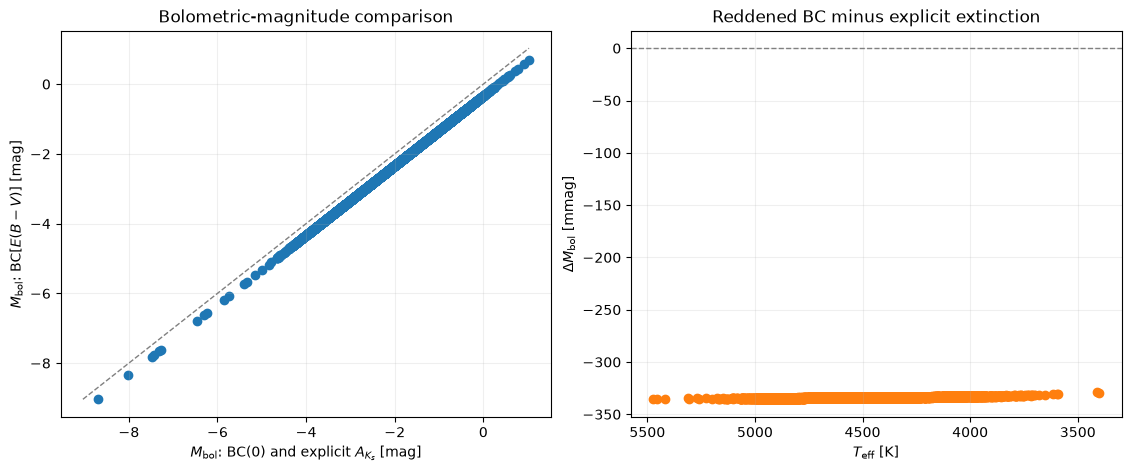

,ID,Teff_K,ebv_median,ak_used_mag,AKs_effective_from_BC_mag,BC_K_0_mag,BC_K_reddened_mag,M_bol_explicit_AK_mag,M_bol_reddened_BC_mag,delta_M_bol_reddened_minus_explicit_mag,L_ratio_reddened_over_explicit
0,2159952732630956032,4535.2954,0.14,0.042364,0.377,-0.115,-0.492,-3.815661,-4.150297,-0.334636,1.360988
1,1650550988346535936,4745.3030,0.14,0.042364,0.377,-0.043,-0.420,-3.766661,-4.101297,-0.334636,1.360988
2,1639308344513006720,4635.1978,0.14,0.042364,0.377,-0.073,-0.450,-3.648661,-3.983297,-0.334636,1.360988
3,1420586516489378176,4863.9980,0.14,0.042364,0.378,-0.019,-0.397,-3.748661,-4.084297,-0.335636,1.362242
4,2161167589900268160,4695.9214,0.14,0.042364,0.377,-0.055,-0.432,-3.139661,-3.474297,-0.334636,1.360988
...,...,...,...,...,...,...,...,...,...,...,...
12563,4623944031185613824,4527.3160,0.14,0.042364,0.376,-0.110,-0.486,-1.842661,-2.176297,-0.333636,1.359735
12564,5288720546730793344,4638.7540,0.14,0.042364,0.377,-0.046,-0.423,-2.033661,-2.368297,-0.334636,1.360988
12565,5260311434008870912,4368.5530,0.14,0.042364,0.376,-0.212,-0.588,-1.857661,-2.191297,-0.333636,1.359735
12566,5293152781179137664,4436.4473,0.14,0.042364,0.376,-0.123,-0.499,-2.363661,-2.697297,-0.333636,1.359735


In [9]:
require_columns(
    dat,
    ["distance_available", "distance_pc", "distance_err_pc",
     "BC_K_0_mag", "BC_K_reddened_mag", "BC_K_0_err_mag",
     "BC_K_reddened_err_mag", "ak_used_mag", "ak_err_used_mag"],
    "the extinction-method comparison",
)

comparison_mask = (
    dat["distance_available"] & dat["extinction_available"] &
    np.isfinite(dat["BC_K_0_mag"]) & np.isfinite(dat["BC_K_reddened_mag"])
)
for column in [
    "AKs_effective_from_BC_mag", "AKs_effective_minus_adopted_mag",
    "M_bol_reddened_BC_mag", "M_bol_reddened_BC_err_mag",
    "M_bol_explicit_AK_mag", "M_bol_explicit_AK_err_mag",
    "delta_M_bol_reddened_minus_explicit_mag", "L_ratio_reddened_over_explicit",
]:
    dat[column] = np.nan

distance_modulus = 5.0 * np.log10(dat.loc[comparison_mask, "distance_pc"]) - 5.0
common_magnitude = dat.loc[comparison_mask, COL["k_mag"]] - distance_modulus
common_error = np.sqrt(
    dat.loc[comparison_mask, COL["k_mag_err"]] ** 2
    + ((5.0 / np.log(10.0))
       * dat.loc[comparison_mask, "distance_err_pc"]
       / dat.loc[comparison_mask, "distance_pc"]) ** 2
)

dat.loc[comparison_mask, "AKs_effective_from_BC_mag"] = (
    dat.loc[comparison_mask, "BC_K_0_mag"]
    - dat.loc[comparison_mask, "BC_K_reddened_mag"]
)
dat.loc[comparison_mask, "AKs_effective_minus_adopted_mag"] = (
    dat.loc[comparison_mask, "AKs_effective_from_BC_mag"]
    - dat.loc[comparison_mask, "ak_used_mag"]
)
dat.loc[comparison_mask, "M_bol_reddened_BC_mag"] = (
    common_magnitude + dat.loc[comparison_mask, "BC_K_reddened_mag"]
)
dat.loc[comparison_mask, "M_bol_reddened_BC_err_mag"] = np.sqrt(
    common_error ** 2 + dat.loc[comparison_mask, "BC_K_reddened_err_mag"] ** 2
)
dat.loc[comparison_mask, "M_bol_explicit_AK_mag"] = (
    common_magnitude - dat.loc[comparison_mask, "ak_used_mag"]
    + dat.loc[comparison_mask, "BC_K_0_mag"]
)
dat.loc[comparison_mask, "M_bol_explicit_AK_err_mag"] = np.sqrt(
    common_error ** 2 + dat.loc[comparison_mask, "ak_err_used_mag"] ** 2
    + dat.loc[comparison_mask, "BC_K_0_err_mag"] ** 2
)
dat.loc[comparison_mask, "delta_M_bol_reddened_minus_explicit_mag"] = (
    dat.loc[comparison_mask, "M_bol_reddened_BC_mag"]
    - dat.loc[comparison_mask, "M_bol_explicit_AK_mag"]
)
dat.loc[comparison_mask, "L_ratio_reddened_over_explicit"] = 10.0 ** (
    -0.4 * dat.loc[comparison_mask, "delta_M_bol_reddened_minus_explicit_mag"]
)

comparison = dat.loc[comparison_mask, [
    COL["id"], "teff_used_K", "ebv_median", "ak_used_mag",
    "AKs_effective_from_BC_mag", "BC_K_0_mag", "BC_K_reddened_mag",
    "M_bol_explicit_AK_mag", "M_bol_reddened_BC_mag",
    "delta_M_bol_reddened_minus_explicit_mag", "L_ratio_reddened_over_explicit",
]].rename(columns={COL["id"]: "ID", "teff_used_K": "Teff_K"})

comparison_path = OUTPUT_DIR / "04_BC_extinction_comparison.csv"
comparison.to_csv(comparison_path, index=False)
print(f"Saved extinction-method comparison: {comparison_path}")
if len(comparison):
    delta_mmag = 1000.0 * comparison["delta_M_bol_reddened_minus_explicit_mag"]
    print(
        "Delta Mbol (reddened BC - explicit AK): "
        f"median={np.nanmedian(delta_mmag):.3f} mmag, "
        f"maximum absolute={np.nanmax(np.abs(delta_mmag)):.3f} mmag"
    )

if COMPARE_EXTINCTION_METHODS and len(comparison):
    fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.6), constrained_layout=True)
    lo = np.nanmin(comparison[["M_bol_explicit_AK_mag", "M_bol_reddened_BC_mag"]])
    hi = np.nanmax(comparison[["M_bol_explicit_AK_mag", "M_bol_reddened_BC_mag"]])
    axes[0].plot([lo, hi], [lo, hi], "--", color="0.5", lw=1)
    axes[0].scatter(
        comparison["M_bol_explicit_AK_mag"], comparison["M_bol_reddened_BC_mag"],
        color="tab:blue"
    )
    axes[0].set_xlabel(r"$M_{\rm bol}$: BC(0) and explicit $A_{K_s}$ [mag]")
    axes[0].set_ylabel(r"$M_{\rm bol}$: BC[$E(B-V)$] [mag]")
    axes[0].set_title("Bolometric-magnitude comparison")

    axes[1].axhline(0.0, ls="--", color="0.5", lw=1)
    axes[1].scatter(
        comparison["Teff_K"],
        1000.0 * comparison["delta_M_bol_reddened_minus_explicit_mag"],
        color="tab:orange",
    )
    axes[1].invert_xaxis()
    axes[1].set_xlabel(r"$T_{\rm eff}$ [K]")
    axes[1].set_ylabel(r"$\Delta M_{\rm bol}$ [mmag]")
    axes[1].set_title("Reddened BC minus explicit extinction")
    for ax in axes:
        ax.grid(alpha=0.2)
    fig.savefig(OUTPUT_DIR / "BC_extinction_comparison.png", dpi=220)
    fig.savefig(OUTPUT_DIR / "BC_extinction_comparison.pdf")
    plt.show()

comparison

## 8. Luminosity and propagated uncertainty

The selected route is controlled by `BC_EXTINCTION_TREATMENT`. For `inside_bc`,
no separate $A_{K_s}$ is subtracted because reddening is already contained in the
BC. For `explicit_ak`, the zero-reddening BC and the adopted $A_{K_s}$ are used.
The uncertainty does not include covariance among inputs or uncertainty in the
Gaia zero-point model.

In [10]:
require_columns(
    dat,
    [
        "distance_available", "distance_pc", "distance_err_pc",
        "extinction_available", "ak_luminosity_mag", "ak_luminosity_err_mag",
        "BC_available", "BC_K_mag", "BC_K_err_mag",
    ],
    "the luminosity calculation",
)

lum_mask = dat["distance_available"] & dat["extinction_available"] & dat["BC_available"]

for name in ["M_Ks_mag", "M_bol_mag", "M_bol_err_mag",
             "Luminosity_Lsun", "Luminosity_err_Lsun"]:
    dat[name] = np.nan

results = bolometric_luminosity(
    dat.loc[lum_mask, COL["k_mag"]].to_numpy(),
    dat.loc[lum_mask, COL["k_mag_err"]].to_numpy(),
    dat.loc[lum_mask, "distance_pc"].to_numpy(),
    dat.loc[lum_mask, "distance_err_pc"].to_numpy(),
    dat.loc[lum_mask, "ak_luminosity_mag"].to_numpy(),
    dat.loc[lum_mask, "ak_luminosity_err_mag"].to_numpy(),
    dat.loc[lum_mask, "BC_K_mag"].to_numpy(),
    dat.loc[lum_mask, "BC_K_err_mag"].to_numpy(),
    M_BOL_SUN,
)
for column, values in zip(
    ["Luminosity_Lsun", "Luminosity_err_Lsun", "M_Ks_mag", "M_bol_mag", "M_bol_err_mag"],
    results,
):
    dat.loc[lum_mask, column] = values

dat["Luminosity_available"] = (
    np.isfinite(dat["Luminosity_Lsun"]) & (dat["Luminosity_Lsun"] > 0) &
    np.isfinite(dat["Luminosity_err_Lsun"]) & (dat["Luminosity_err_Lsun"] >= 0)
)
print(f"Usable luminosities: {dat['Luminosity_available'].sum():,}/{len(dat):,}")

Usable luminosities: 12,130/19,037


/var/folders/gm/qyxx9z714msf_q0yn99ql7vh0000gn/T/ipykernel_35846/752604125.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dat[name] = np.nan
/var/folders/gm/qyxx9z714msf_q0yn99ql7vh0000gn/T/ipykernel_35846/752604125.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dat["Luminosity_available"] = (


## 9. Final catalogue and HR diagram

The compact CSV has the requested columns only: identifier, luminosity and its
uncertainty, effective temperature and its uncertainty. The HR diagram uses the
same values, with the conventional reversed temperature axis.

In [11]:
final = dat.loc[dat["Luminosity_available"], [
    COL["id"], "Luminosity_Lsun", "Luminosity_err_Lsun",
    "teff_used_K", "teff_err_used_K"
]].rename(columns={
    COL["id"]: "ID",
    "teff_used_K": "Teff_K",
    "teff_err_used_K": "Teff_err_K",
})

full_path = OUTPUT_DIR / "cluster_luminosities_full.csv"
compact_path = OUTPUT_DIR / "cluster_luminosities_HRD.csv"
dat.to_csv(full_path, index=False)
final.to_csv(compact_path, index=False)

print(f"Saved full catalogue:    {full_path}")
print(f"Saved compact catalogue: {compact_path}")
final

Saved full catalogue:    ../outputs/FINAL-xmatch_cluster_weighted_median_parallax/cluster_luminosities_full.csv
Saved compact catalogue: ../outputs/FINAL-xmatch_cluster_weighted_median_parallax/cluster_luminosities_HRD.csv


,ID,Luminosity_Lsun,Luminosity_err_Lsun,Teff_K,Teff_err_K
0,2159952732630956032,3631.772224,189.606147,4535.2954,5.145549
1,1650550988346535936,3471.511456,187.843431,4745.3030,5.668209
2,1639308344513006720,3113.999961,181.967097,4635.1978,5.525729
3,1420586516489378176,3417.579318,172.086905,4863.9980,5.993849
4,2161167589900268160,1948.581625,103.459811,4695.9214,5.641769
...,...,...,...,...,...
12563,4623944031185613824,589.547229,41.623823,4527.3160,125.017586
12564,5288720546730793344,703.588290,61.082514,4638.7540,182.625580
12565,5260311434008870912,597.748648,57.870587,4368.5530,173.035580
12566,5293152781179137664,952.617604,97.231750,4436.4473,138.101600


Saved HR diagram: ../outputs/FINAL-xmatch_cluster_weighted_median_parallax/HR_diagram.png and ../outputs/FINAL-xmatch_cluster_weighted_median_parallax/HR_diagram.pdf


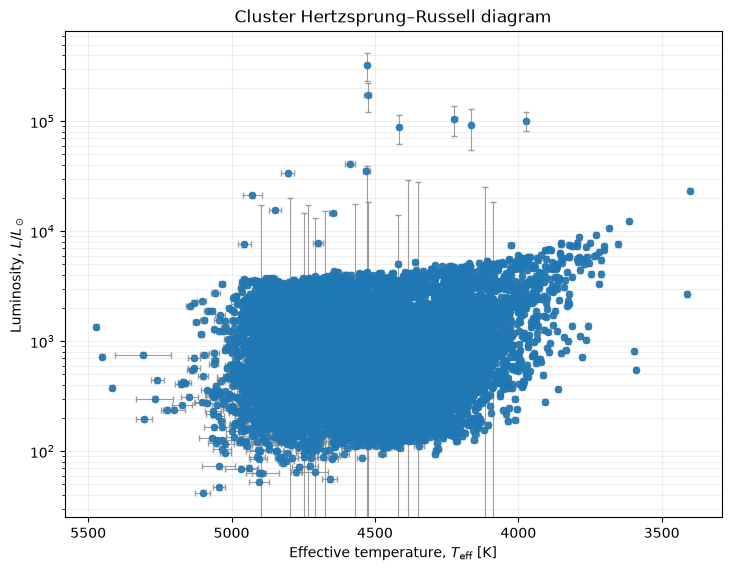

In [12]:
plot_data = final[
    np.isfinite(final["Teff_K"]) & np.isfinite(final["Teff_err_K"]) &
    np.isfinite(final["Luminosity_Lsun"]) &
    np.isfinite(final["Luminosity_err_Lsun"]) &
    (final["Luminosity_Lsun"] > 0)
]

fig, ax = plt.subplots(figsize=(7.2, 5.6), constrained_layout=True)
ax.errorbar(
    plot_data["Teff_K"],
    plot_data["Luminosity_Lsun"],
    xerr=plot_data["Teff_err_K"],
    yerr=plot_data["Luminosity_err_Lsun"],
    fmt="o",
    ms=4.5,
    color="tab:blue",
    ecolor="0.55",
    elinewidth=0.8,
    capsize=2,
    alpha=0.85,
)
ax.set_yscale("log")
ax.invert_xaxis()
ax.set_xlabel(r"Effective temperature, $T_{\rm eff}$ [K]")
ax.set_ylabel(r"Luminosity, $L/L_\odot$")
ax.set_title("Cluster Hertzsprung–Russell diagram")
ax.grid(alpha=0.2, which="both")

png_path = OUTPUT_DIR / "HR_diagram.png"
pdf_path = OUTPUT_DIR / "HR_diagram.pdf"
fig.savefig(png_path, dpi=220)
fig.savefig(pdf_path)
print(f"Saved HR diagram: {png_path} and {pdf_path}")
plt.show()

## 10. Run summary

Keep this short record with the output catalogue when comparing cluster choices.

In [13]:
summary = pd.Series({
    "input_file": str(INPUT_FILE),
    "input_stars": len(dat),
    "output_stars": len(final),
    "distance": distance_description,
    "distance_modulus_kind": (
        DISTANCE_MODULUS_KIND if DISTANCE_MODE == "fixed_distance_modulus" else "not used"
    ),
    "extinction": extinction_description,
    "metallicity": metallicity_description,
    "bc_extinction_treatment": BC_EXTINCTION_TREATMENT,
    "bc_error_mode": BC_ERROR_MODE,
    "M_bol_sun": M_BOL_SUN,
}, name="run configuration")
summary

input_file                                               ../FINAL-xmatch.csv
input_stars                                                            19037
output_stars                                                           12130
distance                   combined RGB+RC inverse-variance weighted-medi...
distance_modulus_kind                                               not used
extinction                                   fixed cluster E(B-V) = 0.14 mag
metallicity                                 individual stellar metallicities
bc_extinction_treatment                                            inside_bc
bc_error_mode                                                    monte_carlo
M_bol_sun                                                               4.75
Name: run configuration, dtype: object